**Install Required Libraries & Setup Environment**

In [24]:
import subprocess, sys
subprocess.run([
    sys.executable, "-m", "pip", "install",
    "mediapipe", "torch-geometric", "torchvision",
    "scipy", "networkx", "tqdm", "matplotlib",
    "imagehash", "pillow", "-q"
], check=False)



CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'mediapipe', 'torch-geometric', 'torchvision', 'scipy', 'networkx', 'tqdm', 'matplotlib', 'imagehash', 'pillow', '-q'], returncode=0)

**Import Libraries, Mount Drive & Configure Paths**

In [25]:
import os, cv2, torch, zipfile, urllib.request
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import random
import hashlib
import shutil
from PIL import Image, ImageEnhance, ImageFilter
import imagehash
from collections import defaultdict
from scipy.spatial import Delaunay
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
import torchvision.models as models
import torchvision.transforms as T
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
import mediapipe as mp
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


**Extract Dataset from ZIP File**

In [26]:
ZIP_PATH        = "/content/drive/MyDrive/RAF-DB.zip"
EXTRACT_PATH    = "/content/drive/MyDrive/RAF-DB_Balance"
CLEANED_PATH    = "/content/drive/MyDrive/RAF-DB_Cleaned"
MODEL_PATH      = "/content/face_landmarker.task"
SAVE_PATH       = "/content/drive/MyDrive/facial_emotion.pth"
CHECKPOINT_PATH = "/content/drive/MyDrive/facial_emotion_checkpoint.pth"

if not os.path.exists(EXTRACT_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_PATH)
        print("Dataset extracted")
else:
    print("Dataset already exists")

Dataset already exists


**Dataset Cleaning & Balancing Functions**

In [ ]:
def show_distribution(path, title):
    print(f"\n📊 {title}\n")
    for split in ["train", "val", "test"]:
        print(f"--- {split.upper()} ---")
        sp = os.path.join(path, split)
        for emo in sorted(os.listdir(sp)):
            ep = os.path.join(sp, emo)
            if os.path.isdir(ep):
                print(f"{emo}: {len(os.listdir(ep))}")
        print()

def file_hash(path):
    try:
        with open(path, 'rb') as f:
            return hashlib.md5(f.read()).hexdigest()
    except:
        return None

def p_hash(path):
    try:
        return imagehash.phash(Image.open(path))
    except:
        return None

def remove_duplicates(path, threshold=5):
    print("\n Removing duplicates (per split)...")
    total_removed = 0

    for split in ["train", "val", "test"]:

        md5_set    = set()
        phash_list = []
        removed    = 0

        sp = os.path.join(path, split)
        if not os.path.exists(sp):
            continue

        for emo in os.listdir(sp):
            ep = os.path.join(sp, emo)
            if not os.path.isdir(ep):
                continue
            for img in os.listdir(ep):
                img_path = os.path.join(ep, img)
                md5 = file_hash(img_path)
                if md5 is None:
                    continue
                if md5 in md5_set:
                    os.remove(img_path)
                    removed += 1
                    continue
                md5_set.add(md5)
                ph = p_hash(img_path)
                if ph is None:
                    continue
                if any(ph - h < threshold for h in phash_list):
                    os.remove(img_path)
                    removed += 1
                else:
                    phash_list.append(ph)

        print(f"  {split}: {removed} duplicates removed")
        total_removed += removed

    print(f"Total duplicates removed: {total_removed}")

In [ ]:
def augment_and_save(src_path, dst_path):
    img = Image.open(src_path).convert("RGB")

    # Random horizontal flip
    if random.random() > 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # Random rotation (-15 to +15 degrees)
    angle = random.uniform(-15, 15)
    img = img.rotate(angle)

    # Random brightness (0.7 to 1.3)
    img = ImageEnhance.Brightness(img).enhance(random.uniform(0.7, 1.3))

    # Random contrast (0.7 to 1.3)
    img = ImageEnhance.Contrast(img).enhance(random.uniform(0.7, 1.3))

    # Random slight blur (30% chance)
    if random.random() < 0.3:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.5, 1.5)))

    img.save(dst_path)

def balance_dataset(path):
    print("\n Balancing TRAIN with augmentation...")
    train_path = os.path.join(path, "train")
    class_files = defaultdict(list)

    for emo in os.listdir(train_path):
        ep = os.path.join(train_path, emo)
        if os.path.isdir(ep):
            class_files[emo] = os.listdir(ep)

    max_count = max(len(v) for v in class_files.values())

    for emo, files in class_files.items():
        ep = os.path.join(train_path, emo)
        needed = max_count - len(files)
        print(f"  {emo}: {len(files)} → {max_count}  (adding {needed} augmented)")
        for i in range(needed):
            src = os.path.join(ep, random.choice(files))
            dst = os.path.join(ep, f"aug_{i}_{random.randint(0,99999)}.jpg")
            augment_and_save(src, dst)

    print("✅ Train balanced with augmentation")

def show_samples(path, num=3):
    train_path = os.path.join(path, "train")
    classes = sorted(os.listdir(train_path))
    plt.figure(figsize=(15, 10))
    for i, emo in enumerate(classes):
        ep = os.path.join(train_path, emo)
        imgs = os.listdir(ep)
        samples = random.sample(imgs, min(num, len(imgs)))
        for j, im in enumerate(samples):
            img = cv2.imread(os.path.join(ep, im))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.subplot(len(classes), num, i*num + j + 1)
            plt.imshow(img)
            plt.axis("off")
            if j == 0:
                plt.ylabel(emo)
    plt.tight_layout()
    plt.show()



📊 BEFORE CLEANING

--- TRAIN ---
angry: 4289
disgust: 4289
fear: 4289
happy: 4289
neutral: 4289
sad: 4289
surprise: 4289

--- VAL ---
angry: 1072
disgust: 1072
fear: 1072
happy: 1072
neutral: 1072
sad: 1072
surprise: 1072

--- TEST ---
angry: 595
disgust: 595
fear: 595
happy: 595
neutral: 595
sad: 595
surprise: 595


 Removing duplicates (per split)...
  train: 10852 duplicates removed
  val: 1157 duplicates removed
  test: 392 duplicates removed
Total duplicates removed: 12401

📊 AFTER DUPLICATE REMOVAL

--- TRAIN ---
angry: 2240
disgust: 2238
fear: 1463
happy: 3988
neutral: 3310
sad: 3125
surprise: 2807

--- VAL ---
angry: 881
disgust: 856
fear: 683
happy: 1054
neutral: 989
sad: 960
surprise: 924

--- TEST ---
angry: 513
disgust: 532
fear: 438
happy: 591
neutral: 574
sad: 569
surprise: 556


 Balancing TRAIN with augmentation...
  angry: 2240 → 3988  (adding 1748 augmented)
  disgust: 2238 → 3988  (adding 1750 augmented)
  fear: 1463 → 3988  (adding 2525 augmented)
  happy: 3988 → 3

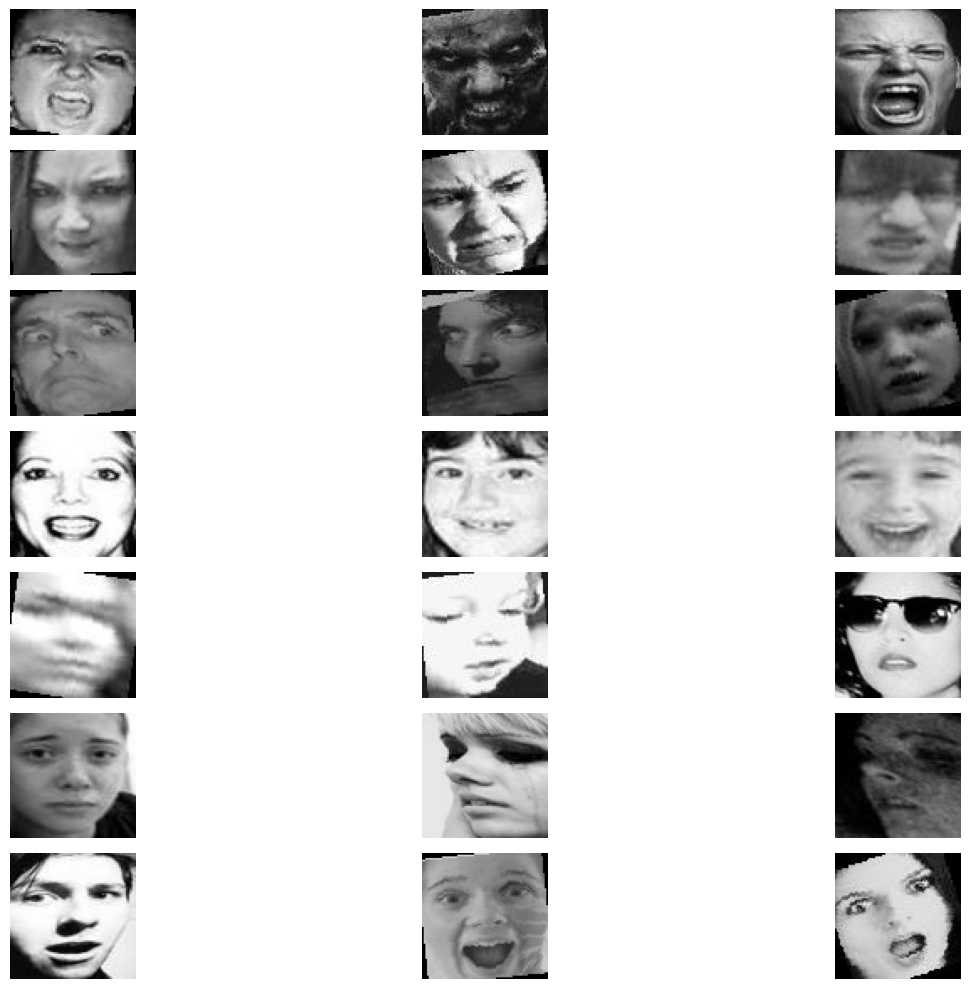

In [ ]:
show_distribution(EXTRACT_PATH, "BEFORE CLEANING")

remove_duplicates(EXTRACT_PATH)

show_distribution(EXTRACT_PATH, "AFTER DUPLICATE REMOVAL")

balance_dataset(EXTRACT_PATH)

show_distribution(EXTRACT_PATH, "AFTER BALANCING")

print(f"\n Saving cleaned dataset to {CLEANED_PATH} ...")

shutil.copytree(EXTRACT_PATH, CLEANED_PATH)

print("✅ Cleaned dataset saved!")

show_samples(CLEANED_PATH, 3)

**Download MediaPipe Face Landmark Model**

In [10]:
if not os.path.exists(MODEL_PATH):
    urllib.request.urlretrieve(
        "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task",
        MODEL_PATH
    )

BaseOptions       = mp.tasks.BaseOptions
FaceLandmarker    = mp.tasks.vision.FaceLandmarker
Options           = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

landmarker = FaceLandmarker.create_from_options(
    Options(
        base_options=BaseOptions(model_asset_path=MODEL_PATH),
        running_mode=VisionRunningMode.IMAGE,
        num_faces=1
    )
)



**Landmark Extraction and Graph Construction**

In [11]:
def extract_landmarks(image):
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)
    if not result.face_landmarks:
        return None
    lm = np.array([[p.x, p.y, p.z] for p in result.face_landmarks[0]])
    lm = (lm - lm.mean(axis=0)) / (lm.std(axis=0) + 1e-6)
    return lm

def build_graph(lm):
    tri = Delaunay(lm[:, :2])
    edges = set()
    for s in tri.simplices:
        for i in range(3):
            a, b = s[i], s[(i+1)%3]
            edges.add((a, b))
            edges.add((b, a))
    edge_index = torch.tensor(list(edges), dtype=torch.long).t().contiguous()
    x = torch.tensor(lm, dtype=torch.float)
    return x, edge_index

**Hybrid Dataset Preparation and DataLoader Setup**

In [12]:
EMOTIONS = ["angry","disgust","fear","happy","neutral","sad","surprise"]

transform = T.Compose([
    T.ToPILImage(),
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor()
])

class HybridDataset(torch.utils.data.Dataset):
    def __init__(self, root):
        self.samples = []
        for label, emo in enumerate(EMOTIONS):
            folder = os.path.join(root, emo)
            if os.path.isdir(folder):
                for img in os.listdir(folder):
                    self.samples.append((os.path.join(folder, img), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = cv2.imread(path)
        if img is None:
            return self.__getitem__((idx + 1) % len(self.samples))
        img = cv2.resize(img, (224, 224))
        img_tensor = transform(img)
        lm = extract_landmarks(img)
        if lm is None:
            return self.__getitem__((idx + 1) % len(self.samples))
        x, edge_index = build_graph(lm)
        data = Data(x=x, edge_index=edge_index, y=torch.tensor(label))
        data.image = img_tensor
        return data

def collate(batch):
    batch = [b for b in batch if b is not None]
    images = torch.stack([b.image for b in batch])
    pyg = Batch.from_data_list(batch)
    pyg.image = images
    return pyg

train_loader = DataLoader(HybridDataset(os.path.join(CLEANED_PATH, "train")),
                          batch_size=32, shuffle=True,  collate_fn=collate, num_workers=0)
val_loader   = DataLoader(HybridDataset(os.path.join(CLEANED_PATH, "val")),
                          batch_size=32, shuffle=False, collate_fn=collate, num_workers=0)
test_loader  = DataLoader(HybridDataset(os.path.join(CLEANED_PATH, "test")),
                          batch_size=32, shuffle=False, collate_fn=collate, num_workers=0)

**Hybrid CNN-GCN Model Architecture**

In [13]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        cnn = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        cnn.fc = nn.Identity()
        self.cnn = cnn
        self.conv1 = GCNConv(3, 128)
        self.conv2 = GCNConv(128, 256)
        self.conv3 = GCNConv(256, 256)
        self.fc = nn.Sequential(
            nn.Linear(2048 + 256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 7)
        )

    def forward(self, data):
        b = data.num_graphs
        img = data.image.view(b, 3, 224, 224).to(device)
        cnn_feat = self.cnn(img)
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        x = self.conv3(x, edge_index).relu()
        gcn_feat = global_mean_pool(x, batch)
        return self.fc(torch.cat([cnn_feat, gcn_feat], dim=1))

**Model Checkpointing and Training Resume**

In [14]:
def save_checkpoint(model, optimizer, epoch, best_f1, counter, path):
    torch.save({
        'epoch':     epoch,
        'model':     model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'best_f1':   best_f1,
        'counter':   counter,
    }, path)
    print(f"Checkpoint saved (epoch {epoch+1}, best_f1={best_f1:.4f})")

def load_checkpoint(model, optimizer, path):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])
    start_epoch = ckpt['epoch'] + 1
    best_f1     = ckpt['best_f1']
    counter     = ckpt['counter']
    print(f"Resumed from epoch {ckpt['epoch']+1}  |  best_f1={best_f1:.4f}  |  patience_counter={counter}")
    return start_epoch, best_f1, counter

**Session 1 Training**

In [ ]:
model     = HybridModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS    = 10
patience  = 2
min_delta = 0.001

if os.path.exists(CHECKPOINT_PATH):
    start_epoch, best_f1, counter = load_checkpoint(model, optimizer, CHECKPOINT_PATH)
else:
    start_epoch = 0
    best_f1     = 0.0
    counter     = 0
    print("Starting training from scratch")

for epoch in range(start_epoch, EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ---- Train ----
    model.train()
    total_loss    = 0
    train_correct = 0
    train_total   = 0

    for batch in tqdm(train_loader, desc="Training"):
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item()
        preds          = out.argmax(dim=1)
        train_correct += (preds == batch.y).sum().item()
        train_total   += batch.y.size(0)

    train_acc = train_correct / train_total

    # ---- Validate ----
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            batch  = batch.to(device)
            out    = model(batch)
            preds  = out.argmax(dim=1).cpu().numpy()
            labels = batch.y.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    val_f1   = f1_score(all_labels, all_preds, average='macro')
    val_acc  = accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / len(train_loader)

    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}")

    # ---- Early stopping + checkpoint ----
    if val_f1 > best_f1 + min_delta:
        best_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Best model saved | Best Val F1: {best_f1:.4f}")
    else:
        counter += 1
        print(f"No improvement. Patience: {counter}/{patience}")

    save_checkpoint(model, optimizer, epoch, best_f1, counter, CHECKPOINT_PATH)

    if counter >= patience:
        print("🛑 Early stopping triggered!")
        break

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


Starting training from scratch

Epoch 1/10


Validation: 100%|██████████| 199/199 [04:59<00:00,  1.50s/it]


Train Acc: 0.6221 | Val Acc: 0.8065
Loss: 1.0014 | Val F1: 0.8076
Best model saved | Best Val F1: 0.8076
Checkpoint saved (epoch 1, best_f1=0.8076)

Epoch 2/10


...

Validation: 100%|██████████| 199/199 [04:08<00:00,  1.25s/it]


Train Acc: 0.9651 | Val Acc: 0.9411
Loss: 0.1028 | Val F1: 0.9439
Best model saved | Best Val F1: 0.9439
Checkpoint saved (epoch 6, best_f1=0.9439)

Epoch 7/10


Validation: 100%|██████████| 199/199 [04:11<00:00,  1.26s/it]


Train Acc: 0.9680 | Val Acc: 0.9478
Loss: 0.0936 | Val F1: 0.9503
Best model saved | Best Val F1: 0.9503
Checkpoint saved (epoch 7, best_f1=0.9503)

Epoch 8/10


Training:  23%|██▎       | 199/873 [05:13<16:12,  1.44s/it]

**Session 2 Training**

In [16]:
model     = HybridModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

EPOCHS    = 10
patience  = 2
min_delta = 0.001

if os.path.exists(CHECKPOINT_PATH):
    start_epoch, best_f1, counter = load_checkpoint(model, optimizer, CHECKPOINT_PATH)
else:
    start_epoch = 0
    best_f1     = 0.0
    counter     = 0
    print("Starting training from scratch")

for epoch in range(start_epoch, EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # ---- Train ----
    model.train()
    total_loss    = 0
    train_correct = 0
    train_total   = 0

    for batch in tqdm(train_loader, desc="Training"):
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss    += loss.item()
        preds          = out.argmax(dim=1)
        train_correct += (preds == batch.y).sum().item()
        train_total   += batch.y.size(0)

    train_acc = train_correct / train_total

    # ---- Validate ----
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validation"):
            batch  = batch.to(device)
            out    = model(batch)
            preds  = out.argmax(dim=1).cpu().numpy()
            labels = batch.y.cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)

    val_f1   = f1_score(all_labels, all_preds, average='macro')
    val_acc  = accuracy_score(all_labels, all_preds)
    avg_loss = total_loss / len(train_loader)

    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    print(f"Loss: {avg_loss:.4f} | Val F1: {val_f1:.4f}")

    # ---- Early stopping + checkpoint ----
    if val_f1 > best_f1 + min_delta:
        best_f1 = val_f1
        counter = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Best model saved | Best Val F1: {best_f1:.4f}")
    else:
        counter += 1
        print(f"No improvement. Patience: {counter}/{patience}")

    save_checkpoint(model, optimizer, epoch, best_f1, counter, CHECKPOINT_PATH)

    if counter >= patience:
        print("🛑 Early stopping triggered!")
        break

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s]


Resumed from epoch 7  |  best_f1=0.9503  |  patience_counter=0

Epoch 8/10


Validation: 100%|██████████| 199/199 [03:38<00:00,  1.10s/it]


Train Acc: 0.9727 | Val Acc: 0.9401
Loss: 0.0812 | Val F1: 0.9426
No improvement. Patience: 1/2
Checkpoint saved (epoch 8, best_f1=0.9503)

Epoch 9/10


Validation: 100%|██████████| 199/199 [03:29<00:00,  1.05s/it]


Train Acc: 0.9742 | Val Acc: 0.9581
Loss: 0.0758 | Val F1: 0.9604
Best model saved | Best Val F1: 0.9604
Checkpoint saved (epoch 9, best_f1=0.9604)

Epoch 10/10


Validation: 100%|██████████| 199/199 [03:24<00:00,  1.03s/it]


Train Acc: 0.9796 | Val Acc: 0.9575
Loss: 0.0615 | Val F1: 0.9594
No improvement. Patience: 1/2
Checkpoint saved (epoch 10, best_f1=0.9604)


**Classification Report**

In [29]:
from sklearn.metrics import classification_report

model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        batch  = batch.to(device)
        out    = model(batch)
        preds  = out.argmax(dim=1).cpu().numpy()
        labels = batch.y.cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels)
print()
print(classification_report(all_labels, all_preds, target_names=EMOTIONS))
print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("Test Macro F1:", f1_score(all_labels, all_preds, average='macro'))

Testing: 100%|██████████| 118/118 [02:02<00:00,  1.03s/it]


              precision    recall  f1-score   support

       angry       0.97      0.97      0.97       511
     disgust       0.94      0.96      0.95       534
        fear       0.99      0.99      0.99       437
       happy       0.98      0.91      0.94       592
     neutral       0.88      0.91      0.89       574
         sad       0.92      0.93      0.93       569
    surprise       0.95      0.97      0.96       556

    accuracy                           0.95      3773
   macro avg       0.95      0.95      0.95      3773
weighted avg       0.95      0.95      0.95      3773

Test Accuracy: 0.9451364961569043
Test Macro F1: 0.9472335427866181


**Confusion Matrix**

<Figure size 1000x800 with 0 Axes>

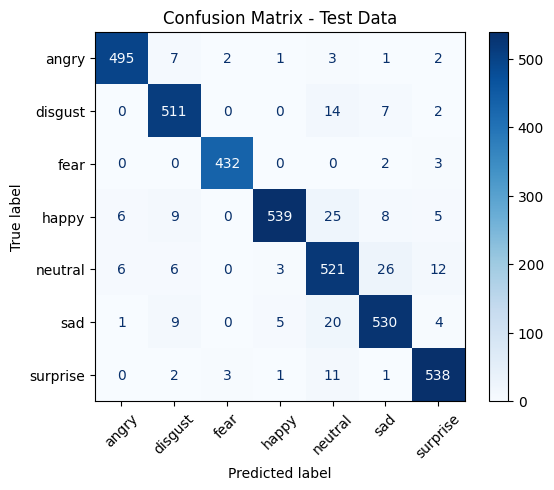

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=EMOTIONS
)

disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix - Test Data")
plt.xticks(rotation=45)

plt.show()